# <center><huge> **Analyse Exploratoire des Données et Mise en œuvre** 

## **Analyse exploratoire du train set**

In [28]:
# Importation des bibliothèques
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
def preparer_dataset(dataset):
    df = pd.DataFrame(dataset)
    df = df[df['label'] != -1].copy() # On enlève les erreurs
    # On crée les colonnes qui nous intéressent
    df['longueur_premisse'] = df['premise'].apply(lambda x: len(str(x).split()))
    df['longueur_hypothese'] = df['hypothesis'].apply(lambda x: len(str(x).split()))
    return df

In [30]:
# Téléchargment des données
snli_train = load_dataset("snli", split="train")
mnli_train = load_dataset("multi_nli", split="train") 
anli_train = load_dataset("anli", split="train_r3")

#Conversion en tableau pandas et netoyage
df_snli_train = preparer_dataset(snli_train)
df_mnli_train = preparer_dataset(mnli_train)
df_anli_train = preparer_dataset(anli_train)

### **Statistiques globaux sur les trains set**

In [31]:
Data_frames = [df_snli_train, df_mnli_train, df_anli_train]
nom_data_set = ["SNLI (train)","MNLI (train)","ANLI (train)"]

#### **Fonction d'analyse exploratoire**

In [ ]:
def analyse_exploratoire(datasets, nom_data_set):
    for dataset, nom in zip(datasets, nom_data_set):
        df = pd.DataFrame(dataset)
        # 1. On filtre et on utilise .copy() pour éviter un warning Pandas (SettingWithCopyWarning)
        df = dataset[dataset['label'] != -1].copy() 
        
        # 2. Affichage des en-têtes
        print(f"\n{'='*40}")
        print(f" Base de données : {nom}")
        print(f"{'='*40}")
        
        # 3. Nombre de paires
        print(f"Nombre de paires Prémisses-Hypothèses : {len(df)}")
        print("-" * 40)
        
        # 4. Équilibre des classes (en pourcentage)
        print("Équilibre des classes (0=Entailment, 1=Neutral, 2=Contradiction) :")
        print((df["label"].value_counts(normalize=True) * 100).round(2).astype(str) + " %")
        print("-" * 40)
        
        # 5. Calcul des longueurs
        df['longueur_premisse'] = df["premise"].apply(lambda x: len(str(x).split()))
        df['longueur_hypothese'] = df['hypothesis'].apply(lambda x: len(str(x).split()))
        
        # 6. Affichage des longueurs.
        print("Longueur moyenne des phrases :")
        # Remarque : on utilise des guillemets simples 'longueur_premisse' à l'intérieur du f-string
        print(f"  - Prémisse   : {df['longueur_premisse'].mean():.2f} mots")
        print(f"  - Hypothèse  : {df['longueur_hypothese'].mean():.2f} mots")
        print(f"{'='*40}\n")

#### Résultats

In [33]:
analyse_exploratoire(Data_frames,nom_data_set)


 Base de données : SNLI (train)
Nombre de paires Prémisses-Hypothèses : 549367
----------------------------------------
Équilibre des classes (0=Entailment, 1=Neutral, 2=Contradiction) :
label
0    33.39 %
2    33.35 %
1    33.27 %
Name: proportion, dtype: str
----------------------------------------
Longueur moyenne des phrases :
  - Prémisse   : 12.85 mots
  - Hypothèse  : 7.42 mots


 Base de données : MNLI (train)
Nombre de paires Prémisses-Hypothèses : 392702
----------------------------------------
Équilibre des classes (0=Entailment, 1=Neutral, 2=Contradiction) :
label
2    33.33 %
1    33.33 %
0    33.33 %
Name: proportion, dtype: str
----------------------------------------
Longueur moyenne des phrases :
  - Prémisse   : 19.81 mots
  - Hypothèse  : 9.97 mots


 Base de données : ANLI (train)
Nombre de paires Prémisses-Hypothèses : 100459
----------------------------------------
Équilibre des classes (0=Entailment, 1=Neutral, 2=Contradiction) :
label
1    40.59 %
0    32.14 %


### **Comparaison des longeurs des prémisses et hypothèses**

#### **Fonction d'analyse de la longeur**

In [34]:
def comparer_longueurs_kde(liste_dfs, liste_noms, colonne_texte="hypothesis", limite_x=45, nom_fichier="comparaison_kde_train.png", titre=None):
    """
    Génère un graphique de densité (KDE) pour comparer la longueur des phrases.
    
    Paramètres :
    - liste_dfs : Liste des DataFrames [df_snli, df_mnli, df_anli]
    - liste_noms : Liste des noms pour la légende ['SNLI', 'MNLI', 'ANLI']
    - colonne_texte : 'hypothesis' ou 'premise' (la colonne contenant le texte)
    - limite_x : L'axe X maximum pour bien voir la courbe (45 pour hypothèse, plus pour prémisse)
    """
    if len(liste_dfs) != len(liste_noms):
        raise ValueError("Erreur : Il faut autant de noms que de DataFrames !")
        
    plt.figure(figsize=(10, 6))
    
    # Nom de la future colonne de longueur (ex: 'longueur_hypothesis')
    col_longueur = f"longueur_{colonne_texte}"
    
    # Tracé dynamique pour chaque dataset
    for df, nom in zip(liste_dfs, liste_noms):
        df_temp = df.copy() # Copie de sécurité
        
        # Si la longueur n'a pas encore été calculée, on le fait à la volée !
        if col_longueur not in df_temp.columns:
            print(f"Calcul de la longueur de '{colonne_texte}' pour {nom}...")
            df_temp[col_longueur] = df_temp[colonne_texte].apply(lambda x: len(str(x).split()))
            
        # On trace la courbe de densité
        sns.kdeplot(df_temp[col_longueur], label=nom, fill=True, alpha=0.5)

    # Titre dynamique par défaut si aucun titre n'est fourni
    if titre is None:
        mot_francais = "hypothèses" if colonne_texte == "hypothesis" else "prémisses"
        titre = f"Évolution de la complexité des {mot_francais}"

    # Personnalisation "Rapport Scientifique"
    plt.title(titre, fontsize=14, pad=15)
    
    # Label de l'axe X qui s'adapte automatiquement (Prémisse ou Hypothèse)
    mot_axe = "l'hypothèse" if colonne_texte == "hypothesis" else "la prémisse"
    plt.xlabel(f"Nombre de mots dans {mot_axe}", fontsize=12)
    
    plt.ylabel("Densité de probabilité", fontsize=12)
    plt.xlim(0, limite_x)
    plt.legend(fontsize=11, title="Corpus")
    plt.grid(axis='y', alpha=0.3)
    
    plt.savefig(nom_fichier, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\n✅ Graphique sauvegardé : {nom_fichier}")

##### **Pour les prémisses**

Calcul de la longueur de 'premise' pour SNLI (train)...
Calcul de la longueur de 'premise' pour MNLI (train)...
Calcul de la longueur de 'premise' pour ANLI (train)...


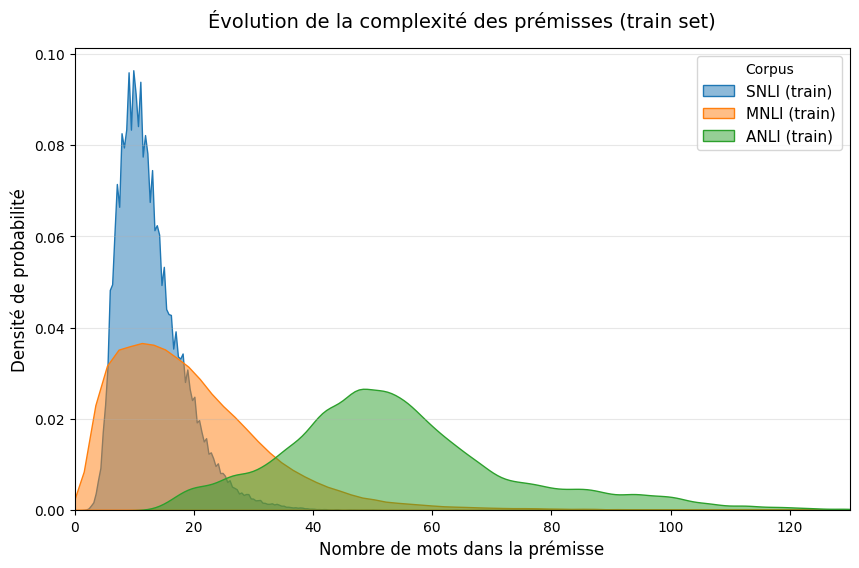


✅ Graphique sauvegardé : comparaison_longueur_premisses_TrainSet.png


In [35]:
comparer_longueurs_kde(
    liste_dfs= Data_frames,
    liste_noms= nom_data_set,
    colonne_texte= 'premise',
    nom_fichier= 'comparaison_longueur_premisses_TrainSet.png',
    titre= "Évolution de la complexité des prémisses (train set)",
    limite_x= 130  
)

##### **Pour les hypothèses**

Calcul de la longueur de 'hypothesis' pour SNLI (train)...
Calcul de la longueur de 'hypothesis' pour MNLI (train)...
Calcul de la longueur de 'hypothesis' pour ANLI (train)...


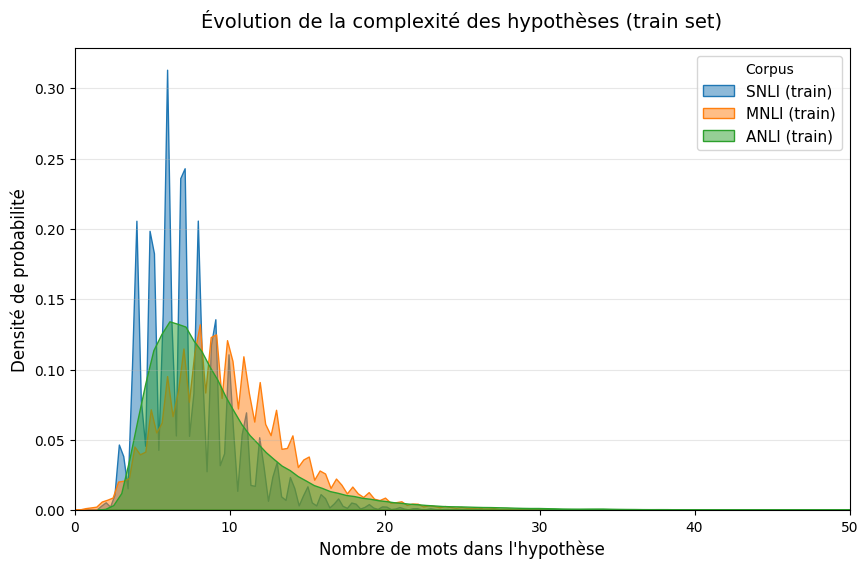


✅ Graphique sauvegardé : comparaison_longueur_hypothese_TrainSet.png


In [36]:
comparer_longueurs_kde(
    liste_dfs= Data_frames,
    liste_noms= nom_data_set,
    colonne_texte= 'hypothesis',
    nom_fichier= 'comparaison_longueur_hypothese_TrainSet.png',
    titre= "Évolution de la complexité des hypothèses (train set)",
    limite_x= 50  
)

### **Comparaison des chevauchements lexicaux**

#### **fonction d'analyse des chevauchements lexicaux**

In [37]:
def calculer_chevauchement(row):
    """Calcule le taux de mots de l'hypothèse présents dans la prémisse."""
    mots_premisse = set(str(row['premise']).lower().split())
    mots_hypothese = set(str(row['hypothesis']).lower().split())
    
    if len(mots_hypothese) == 0:
        return 0.0
        
    mots_en_commun = mots_premisse.intersection(mots_hypothese)
    return len(mots_en_commun) / len(mots_hypothese)


def comparer_chevauchements(liste_dfs, liste_noms, nom_fichier="biais_chevauchement_train.png", titre="Le Biais de Chevauchement Lexical des train set"):
    """
    Prend une liste de DataFrames et génère un Boxplot comparatif.
    """
    if len(liste_dfs) != len(liste_noms):
        raise ValueError("Erreur : Il faut autant de noms que de DataFrames !")
        
    dfs_a_combiner = []
    
    # 1. Traitement de chaque dataset de la liste
    for df, nom in zip(liste_dfs, liste_noms):
        # On fait une copie pour ne pas altérer le dataset original en mémoire
        df_temp = df.copy()
        
        # On calcule le chevauchement uniquement s'il n'a pas déjà été fait
        if 'chevauchement' not in df_temp.columns:
            print(f"Calcul du chevauchement pour {nom}...")
            df_temp['chevauchement'] = df_temp.apply(calculer_chevauchement, axis=1)
            
        # On étiquette les données
        df_temp['Dataset'] = nom
        
        # On garde uniquement les 3 colonnes utiles pour alléger la mémoire
        dfs_a_combiner.append(df_temp[['chevauchement', 'Dataset', 'label']])
        
    # 2. Concaténation automatique
    df_combine = pd.concat(dfs_a_combiner, ignore_index=True)
    
    # 3. Préparation des labels
    noms_labels = {0: 'Entailment', 1: 'Neutral', 2: 'Contradiction'}
    df_combine['Relation'] = df_combine['label'].map(noms_labels)
    
    # 4. Dessin du graphique
    plt.figure(figsize=(10, 6))
    
    # On laisse seaborn choisir dynamiquement les couleurs s'il y a plus de 3 datasets
    sns.boxplot(x='Relation', y='chevauchement', hue='Dataset', data=df_combine)
    
    plt.title(titre, fontsize=14, pad=15)
    plt.xlabel("Relation Logique", fontsize=12)
    plt.ylabel("Taux de mots en commun (0 à 1)", fontsize=12)
    plt.legend(title="Corpus")
    plt.grid(axis='y', alpha=0.3)
    
    # Sauvegarde et affichage
    plt.savefig(nom_fichier, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\n✅ Graphique sauvegardé avec succès sous le nom : {nom_fichier}")

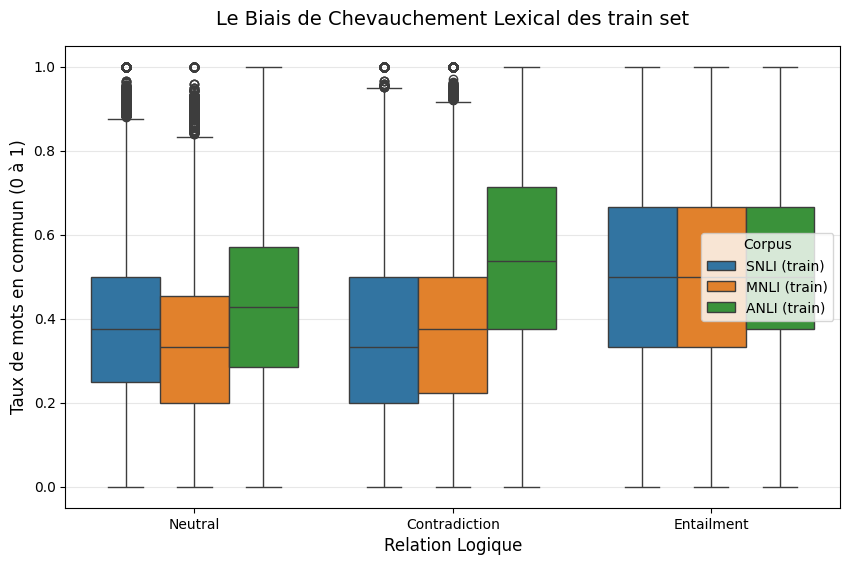


✅ Graphique sauvegardé avec succès sous le nom : biais_chevauchement_train.png


In [38]:
df_snli_train['chevauchement'] = df_snli_train.apply(calculer_chevauchement, axis=1)
df_mnli_train['chevauchement'] = df_mnli_train.apply(calculer_chevauchement, axis=1)
df_anli_train['chevauchement'] = df_anli_train.apply(calculer_chevauchement, axis=1)

comparer_chevauchements(Data_frames,nom_data_set)


## **Analyse exploratoire du validation set**

In [39]:
snli_val = load_dataset("snli", split="validation")
mnli_val = load_dataset("multi_nli", split="validation_matched") 
anli_val = load_dataset("anli", split="dev_r3") # Pour ANLI, la validation s'appelle 'dev'

df_snli_val = preparer_dataset(snli_val)
df_mnli_val = preparer_dataset(mnli_val)
df_anli_val = preparer_dataset(anli_val)

### **Statistiques globaux sur les validations sets**

In [40]:
Data_frames = [df_snli_val, df_mnli_val, df_anli_val]
nom_data_set = ["SNLI (validation)","MNLI (validation)","ANLI (validation)"]

#### **Résultats**

In [41]:
analyse_exploratoire(Data_frames,nom_data_set)


 Base de données : SNLI (validation)
Nombre de paires Prémisses-Hypothèses : 9842
----------------------------------------
Équilibre des classes (0=Entailment, 1=Neutral, 2=Contradiction) :
label
0    33.82 %
2    33.31 %
1    32.87 %
Name: proportion, dtype: str
----------------------------------------
Longueur moyenne des phrases :
  - Prémisse   : 13.94 mots
  - Hypothèse  : 7.51 mots


 Base de données : MNLI (validation)
Nombre de paires Prémisses-Hypothèses : 9815
----------------------------------------
Équilibre des classes (0=Entailment, 1=Neutral, 2=Contradiction) :
label
0    35.45 %
2    32.74 %
1    31.82 %
Name: proportion, dtype: str
----------------------------------------
Longueur moyenne des phrases :
  - Prémisse   : 19.27 mots
  - Hypothèse  : 9.92 mots


 Base de données : ANLI (validation)
Nombre de paires Prémisses-Hypothèses : 1200
----------------------------------------
Équilibre des classes (0=Entailment, 1=Neutral, 2=Contradiction) :
label
0    33.5 %
1    

### **Comparaison des longeurs des prémisses et hypothèses**

##### **Pour les prémisses**

Calcul de la longueur de 'premise' pour SNLI (validation)...
Calcul de la longueur de 'premise' pour MNLI (validation)...
Calcul de la longueur de 'premise' pour ANLI (validation)...


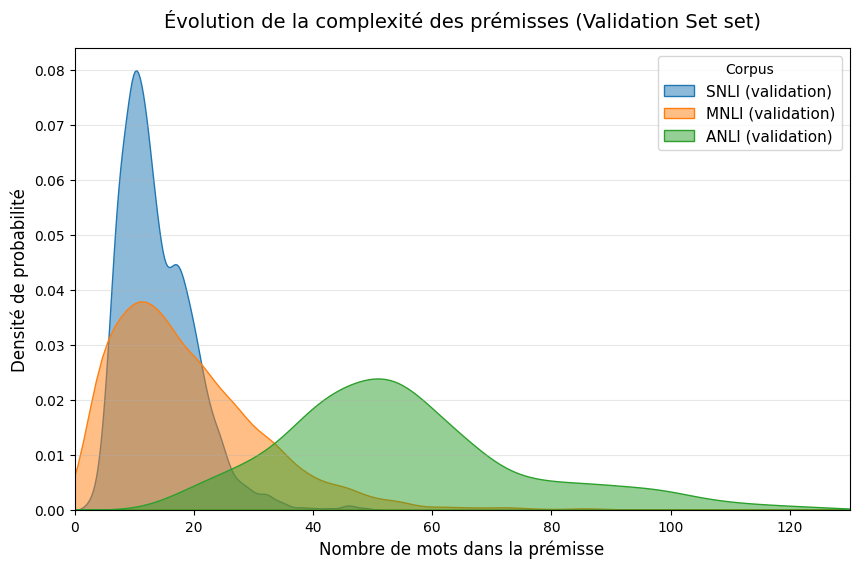


✅ Graphique sauvegardé : comparaison_longueur_premisses_Validation_Set.png


In [42]:
comparer_longueurs_kde(
    liste_dfs= Data_frames,
    liste_noms= nom_data_set,
    colonne_texte= 'premise',
    nom_fichier= 'comparaison_longueur_premisses_Validation_Set.png',
    titre= "Évolution de la complexité des prémisses (Validation Set set)",
    limite_x= 130  
)

##### **Pour les hypothèses**

Calcul de la longueur de 'hypothesis' pour SNLI (validation)...
Calcul de la longueur de 'hypothesis' pour MNLI (validation)...
Calcul de la longueur de 'hypothesis' pour ANLI (validation)...


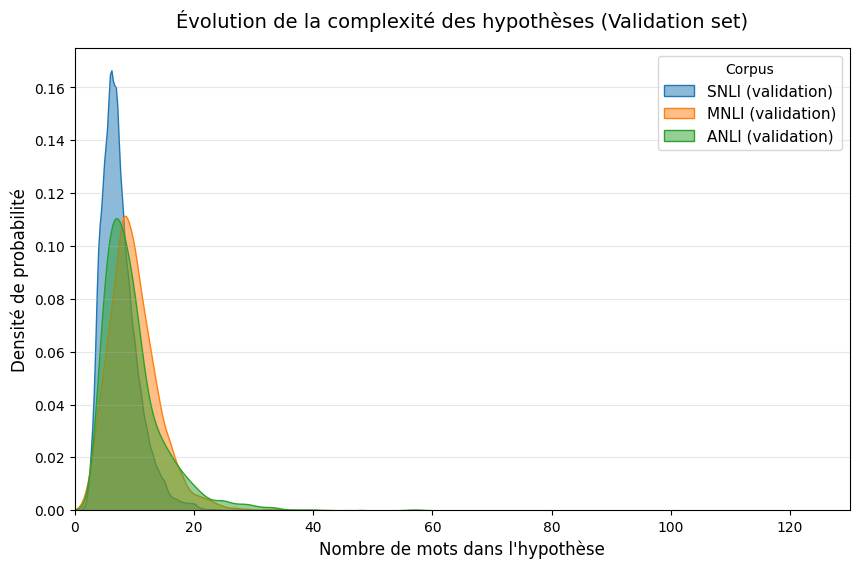


✅ Graphique sauvegardé : comparaison_longueur_hypothese_Validation_Set.png


In [43]:
comparer_longueurs_kde(
    liste_dfs= Data_frames,
    liste_noms= nom_data_set,
    colonne_texte= 'hypothesis',
    nom_fichier= 'comparaison_longueur_hypothese_Validation_Set.png',
    titre= "Évolution de la complexité des hypothèses (Validation set)",
    limite_x= 130  
)

### **Comparaison des chevauchements lexicaux**

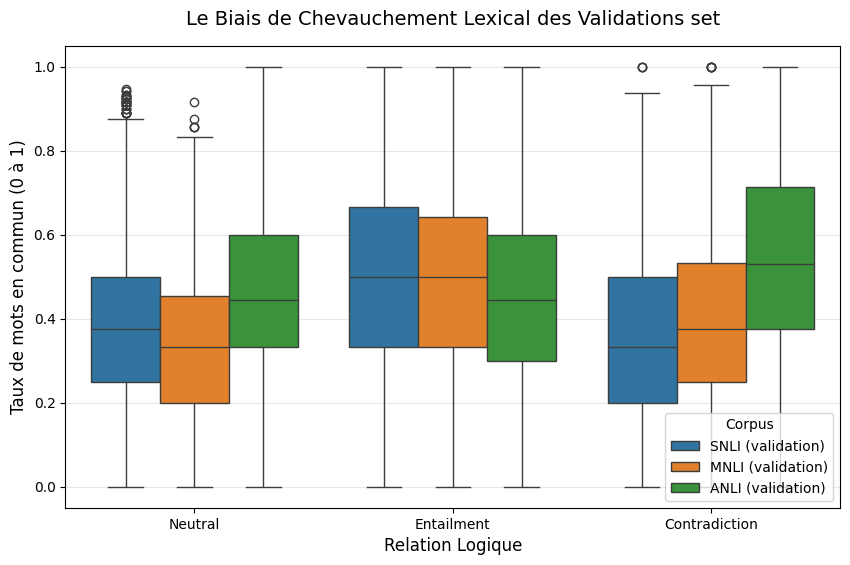


✅ Graphique sauvegardé avec succès sous le nom : biais_chevauchement_Validation Set.png


In [44]:
df_snli_val['chevauchement'] = df_snli_val.apply(calculer_chevauchement, axis=1)
df_mnli_val['chevauchement'] = df_mnli_val.apply(calculer_chevauchement, axis=1)
df_anli_val['chevauchement'] = df_anli_val.apply(calculer_chevauchement, axis=1)
comparer_chevauchements( Data_frames,nom_data_set,nom_fichier="biais_chevauchement_Validation Set.png", titre="Le Biais de Chevauchement Lexical des Validations set")


## **Analyse exploratoire du test set**

In [45]:
# Chargement des données 
snli_test = load_dataset("snli", split="test")
mnli_test = load_dataset("multi_nli", split="validation_matched") 
anli_test = load_dataset("anli", split="test_r3")

df_snli_test = preparer_dataset(snli_test)
df_mnli_test = preparer_dataset(mnli_test)
df_anli_test = preparer_dataset(anli_test)

### **Statistiques globaux sur les validations sets**

In [46]:
Data_frames = [df_snli_test, df_mnli_test, df_anli_test]
nom_data_set = ["SNLI (Test)","MNLI (Test)","ANLI (Test)"]

#### **Résultats**

In [47]:
analyse_exploratoire(Data_frames,nom_data_set)


 Base de données : SNLI (Test)
Nombre de paires Prémisses-Hypothèses : 9824
----------------------------------------
Équilibre des classes (0=Entailment, 1=Neutral, 2=Contradiction) :
label
0    34.28 %
2    32.95 %
1    32.77 %
Name: proportion, dtype: str
----------------------------------------
Longueur moyenne des phrases :
  - Prémisse   : 13.91 mots
  - Hypothèse  : 7.48 mots


 Base de données : MNLI (Test)
Nombre de paires Prémisses-Hypothèses : 9815
----------------------------------------
Équilibre des classes (0=Entailment, 1=Neutral, 2=Contradiction) :
label
0    35.45 %
2    32.74 %
1    31.82 %
Name: proportion, dtype: str
----------------------------------------
Longueur moyenne des phrases :
  - Prémisse   : 19.27 mots
  - Hypothèse  : 9.92 mots


 Base de données : ANLI (Test)
Nombre de paires Prémisses-Hypothèses : 1200
----------------------------------------
Équilibre des classes (0=Entailment, 1=Neutral, 2=Contradiction) :
label
0    33.5 %
1    33.5 %
2    33.0 %

### **Comparaison des longeurs des prémisses et hypothèses**

##### **Pour les prémisses**

Calcul de la longueur de 'premise' pour SNLI (Test)...
Calcul de la longueur de 'premise' pour MNLI (Test)...
Calcul de la longueur de 'premise' pour ANLI (Test)...


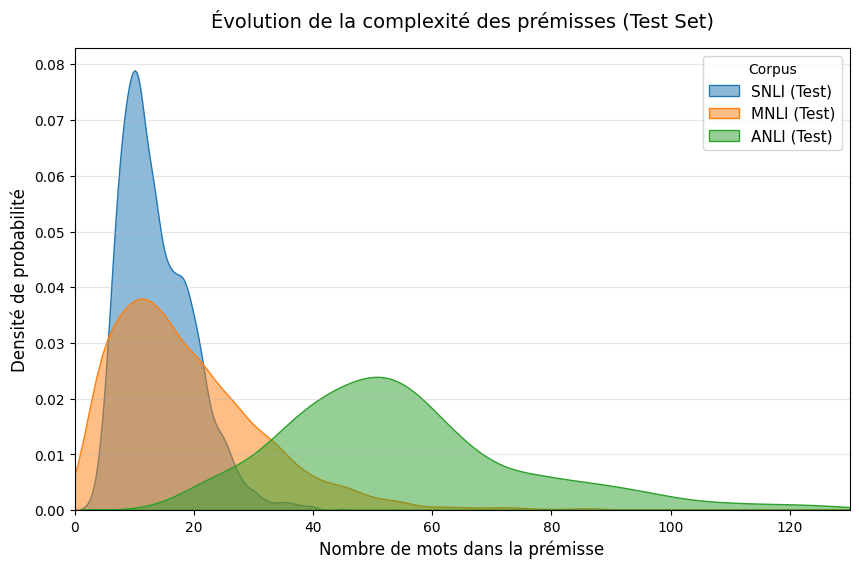


✅ Graphique sauvegardé : comparaison_longueur_premisses_Test_Set.png


In [48]:
comparer_longueurs_kde(
    liste_dfs= Data_frames,
    liste_noms= nom_data_set,
    colonne_texte= 'premise',
    nom_fichier= 'comparaison_longueur_premisses_Test_Set.png',
    titre= "Évolution de la complexité des prémisses (Test Set)",
    limite_x= 130  
)

##### **Pour les hypothèses**

Calcul de la longueur de 'hypothesis' pour SNLI (Test)...
Calcul de la longueur de 'hypothesis' pour MNLI (Test)...
Calcul de la longueur de 'hypothesis' pour ANLI (Test)...


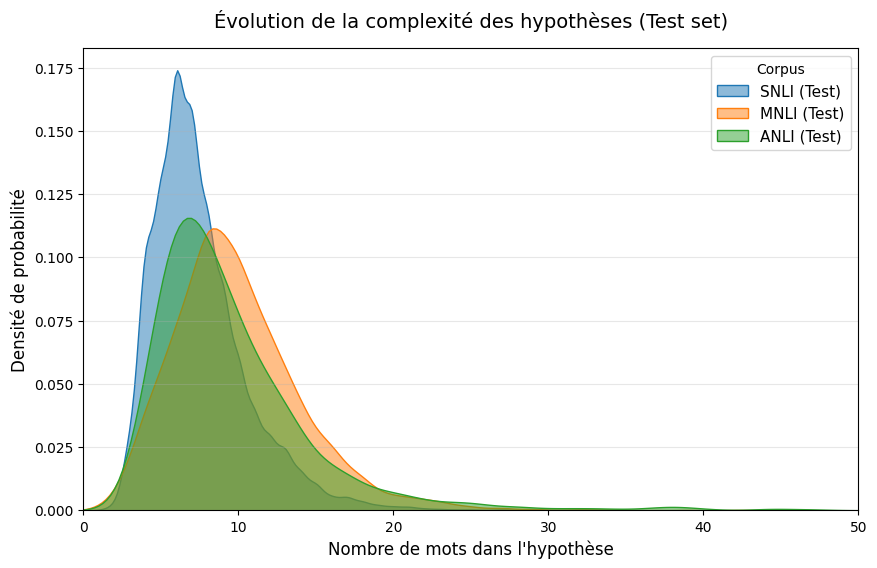


✅ Graphique sauvegardé : comparaison_longueur_hypothese_Test_Set.png


In [49]:
comparer_longueurs_kde(
    liste_dfs= Data_frames,
    liste_noms= nom_data_set,
    colonne_texte= 'hypothesis',
    nom_fichier= 'comparaison_longueur_hypothese_Test_Set.png',
    titre= "Évolution de la complexité des hypothèses (Test set)",
    limite_x= 50  
)

### **Comparaison des chevauchements lexicaux**

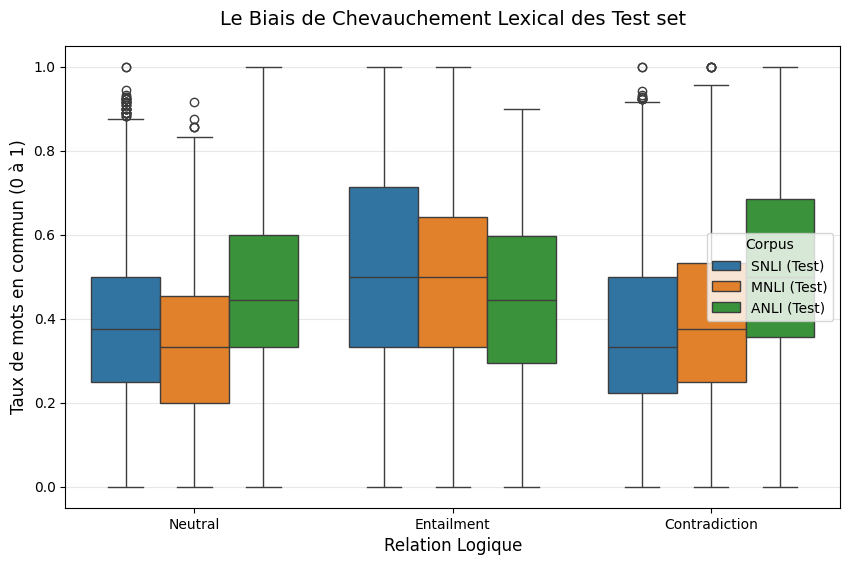


✅ Graphique sauvegardé avec succès sous le nom : biais_chevauchement_Test_set.png


In [50]:
df_snli_test['chevauchement'] = df_snli_test.apply(calculer_chevauchement, axis=1)
df_mnli_test['chevauchement'] = df_mnli_test.apply(calculer_chevauchement, axis=1)
df_anli_test['chevauchement'] = df_anli_test.apply(calculer_chevauchement, axis=1)
comparer_chevauchements( Data_frames,nom_data_set,nom_fichier="biais_chevauchement_Test_set.png", titre="Le Biais de Chevauchement Lexical des Test set")


Téléchargement du corpus HANS...
✅ Nombre total de phrases pièges dans HANS : 30000

Aperçu des données calculées :


,premise,hypothesis,label,heuristic,chevauchement
0,The president advised the doctor .,The doctor advised the president .,1,lexical_overlap,1.0
1,The student saw the managers .,The managers saw the student .,1,lexical_overlap,1.0
2,The presidents encouraged the banker .,The banker encouraged the presidents .,1,lexical_overlap,1.0


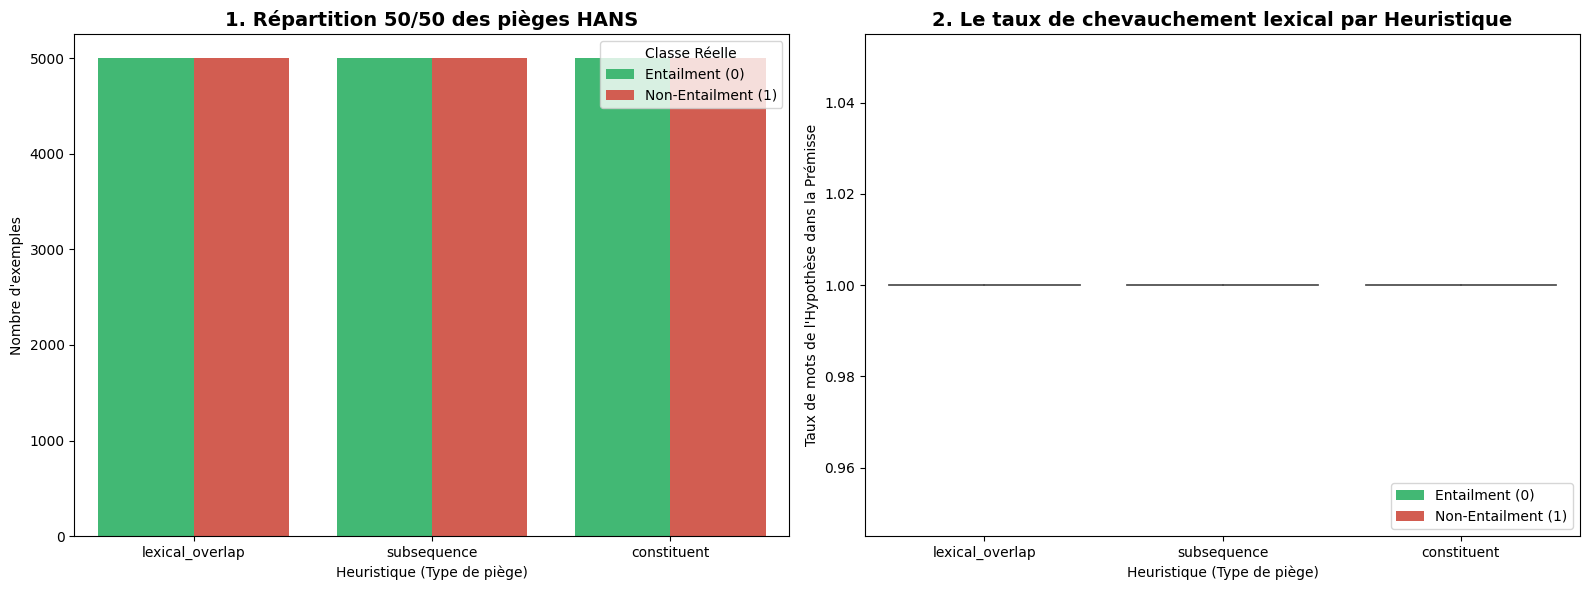


⚠️ Preuve du biais : Sur l'heuristique 'lexical_overlap', 100.0% des mots de l'hypothèse sont présents dans la prémisse, MÊME quand c'est une contradiction !


In [52]:
# ==========================================
# 3. Analyse Exploratoire du Dataset HANS
# ==========================================

print("Téléchargement du corpus HANS...")
hans_dataset = load_dataset("hans", revision="refs/convert/parquet")
#HANS s'évalue uniquement sur son set de validation (qui sert de test)
df_hans = pd.DataFrame(hans_dataset['validation'])

print(f"✅ Nombre total de phrases pièges dans HANS : {len(df_hans)}")

# ---------------------------------------------------------
# A. Application de tes fonctions de calcul (Longueur et Chevauchement)
# ---------------------------------------------------------

# 1. Calcul de la longueur (en mots)
df_hans['longueur_premisse'] = df_hans['premise'].apply(lambda x: len(str(x).split()))
df_hans['longueur_hypothese'] = df_hans['hypothesis'].apply(lambda x: len(str(x).split()))

# 2. Réutilisation de ta fonction de chevauchement lexical
def calculer_chevauchement(row):
    mots_premisse = set(str(row['premise']).lower().split())
    mots_hypothese = set(str(row['hypothesis']).lower().split())
    
    # Sécurité pour éviter la division par zéro
    if len(mots_hypothese) == 0:
        return 0.0
        
    mots_communs = mots_hypothese.intersection(mots_premisse)
    return len(mots_communs) / len(mots_hypothese)

# Application de la fonction
df_hans['chevauchement'] = df_hans.apply(calculer_chevauchement, axis=1)

print("\nAperçu des données calculées :")
display(df_hans[['premise', 'hypothesis', 'label', 'heuristic', 'chevauchement']].head(3))

# ---------------------------------------------------------
# B. Visualisations : La preuve du piège HANS
# ---------------------------------------------------------

# Définition d'une palette claire (0 = Entailment, 1 = Non-Entailment)
couleurs_labels = {0: '#2ecc71', 1: '#e74c3c'} # Vert et Rouge

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1 : La répartition parfaite des classes par heuristique
sns.countplot(
    data=df_hans, 
    x='heuristic', 
    hue='label', 
    palette=couleurs_labels,
    ax=axes[0]
)
axes[0].set_title("1. Répartition 50/50 des pièges HANS", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Heuristique (Type de piège)")
axes[0].set_ylabel("Nombre d'exemples")
# Renommer la légende pour que ce soit clair
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles, labels=['Entailment (0)', 'Non-Entailment (1)'], title="Classe Réelle")

# Graphique 2 : L'analyse de ton chevauchement lexical sur HANS
# C'est LE graphique qui prouve pourquoi BERT va se tromper
sns.violinplot(
    data=df_hans, 
    x='heuristic', 
    y='chevauchement', 
    hue='label',
    split=True, 
    inner="quart", 
    palette=couleurs_labels,
    ax=axes[1]
)
axes[1].set_title("2. Le taux de chevauchement lexical par Heuristique", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Heuristique (Type de piège)")
axes[1].set_ylabel("Taux de mots de l'Hypothèse dans la Prémisse")
axes[1].legend(handles=handles, labels=['Entailment (0)', 'Non-Entailment (1)'], loc='lower right')

plt.tight_layout()
plt.savefig("biais_chevauchement_HANS_répartition.png", dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# C. Preuve statistique à mettre dans le rapport
# ---------------------------------------------------------
chevauchement_moyen = df_hans[df_hans['heuristic'] == 'lexical_overlap']['chevauchement'].mean()
print(f"\n⚠️ Preuve du biais : Sur l'heuristique 'lexical_overlap', {chevauchement_moyen*100:.1f}% des mots de l'hypothèse sont présents dans la prémisse, MÊME quand c'est une contradiction !")